# Cell 1: Setup

In [1]:
import sys
sys.path.insert(0, '..')

from src.search_engine import PhoneticSearchEngine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

sns.set_style('whitegrid')

# Cell 2: Load Engine with Full Database

In [2]:
print("Loading phonetic search engine...")
engine = PhoneticSearchEngine()
engine.load_data('../data/cmudict-0.7b.txt')
engine.build_index()
print(f"Loaded {len(engine.words)} words")

Loading phonetic search engine...
Loaded 125067 words
Encoding words...
Generating embeddings...
Building FAISS index...
Index built successfully!
Loaded 125067 words


# Cell 3: Load Evaluation Results

In [3]:
eval_df = pd.read_csv('../results/full_evaluation.csv')
print("EVALUATION METRICS")
print(eval_df.to_string(index=False))

EVALUATION METRICS
                Metric   Value
 Retrieval Accuracy @1  85.25%
 Retrieval Accuracy @5  99.66%
Retrieval Accuracy @10 100.00%
  Avg Distance (Top-1)       0
  Avg Search Time (ms)   44.86
    Total Words Tested   10000
         Database Size  125067


# Cell 4: Accuracy Visualization

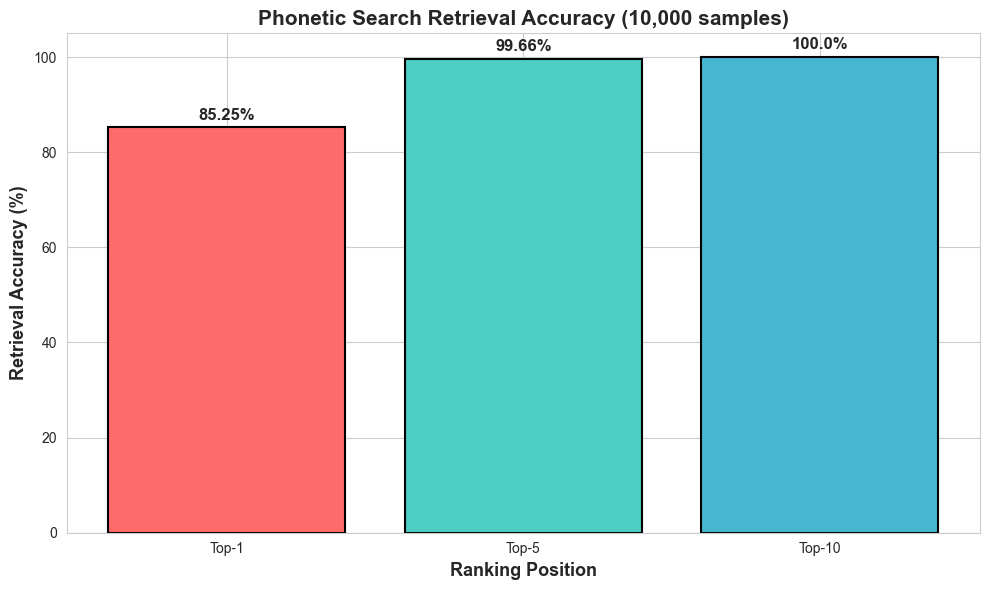

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Top-1', 'Top-5', 'Top-10']
values = [85.25, 99.66, 100.0]
bars = ax.bar(metrics, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=1.5)
ax.set_ylabel('Retrieval Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ranking Position', fontsize=13, fontweight='bold')
ax.set_title('Phonetic Search Retrieval Accuracy (10,000 samples)', fontsize=15, fontweight='bold')
ax.set_ylim(0, 105)
for bar, v in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{v}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/accuracy_chart.png', dpi=500, bbox_inches='tight')
plt.show()

# Cell 5: Distance Distribution from Database

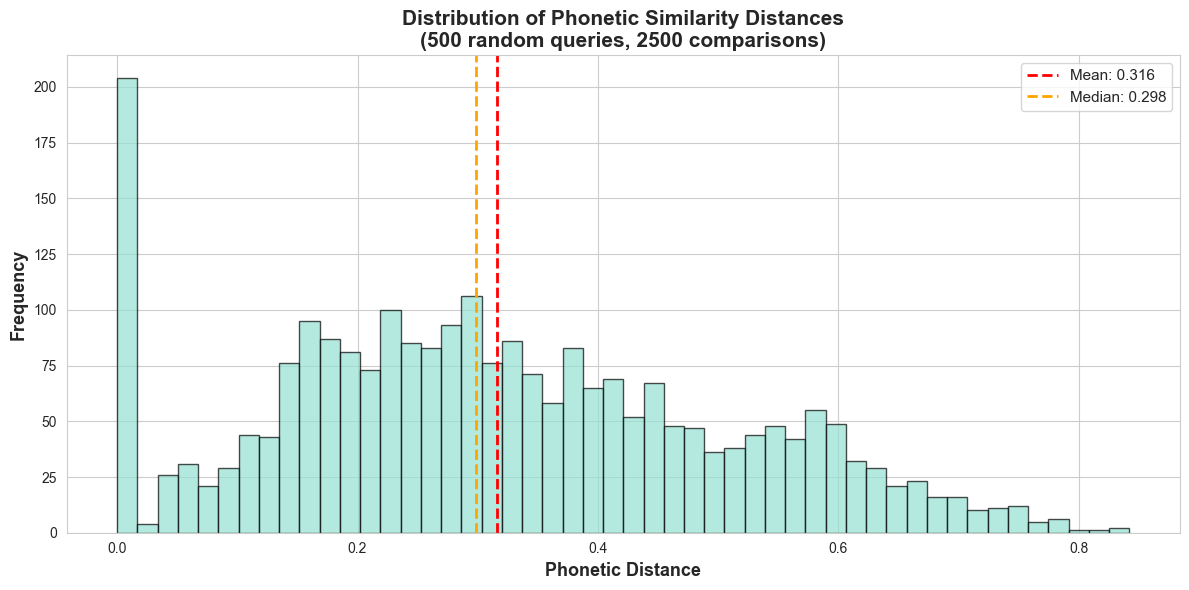

Mean Distance: 0.3157
Median Distance: 0.2985
Std Dev: 0.1881


In [5]:
print("\nCollecting distance metrics from 500 random queries...")
all_distances = []
sample_words = random.sample(engine.words, 500)

for word in sample_words:
    results = engine.search(word, top_k=10)
    # Collect distances for non-exact matches
    all_distances.extend([r['distance'] for r in results[1:6]])  # Top 2-6 results

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(all_distances, bins=50, color='#95E1D3', edgecolor='black', alpha=0.7)
ax.set_xlabel('Phonetic Distance', fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Phonetic Similarity Distances\n(500 random queries, 2500 comparisons)', 
             fontsize=15, fontweight='bold')
ax.axvline(np.mean(all_distances), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_distances):.3f}')
ax.axvline(np.median(all_distances), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(all_distances):.3f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../results/distance_distribution.png', dpi=500, bbox_inches='tight')
plt.show()

print(f"Mean Distance: {np.mean(all_distances):.4f}")
print(f"Median Distance: {np.median(all_distances):.4f}")
print(f"Std Dev: {np.std(all_distances):.4f}")

# Cell 6: Real Example Results from Database

In [6]:
print("SAMPLE PHONETIC MATCHES FROM DATABASE")

test_words = random.sample(engine.words, 5)
examples = []

for word in test_words:
    results = engine.search(word, top_k=5)
    top_matches = ', '.join([r['word'] for r in results[:5]])
    examples.append({'Query': word, 'Top 5 Matches': top_matches})

examples_df = pd.DataFrame(examples)
print(examples_df.to_string(index=False))
examples_df.to_csv('../results/example_results.csv', index=False)

SAMPLE PHONETIC MATCHES FROM DATABASE
    Query                                                  Top 5 Matches
laningham laningham, vanlaningham, landingham, winningham, vanlandingham
      cap                                     cap, capp, kapp, yap, yapp
   tullar                        tullar, tuller, stuller, muller, colour
   karach                         karach, carron, karren, carrol, carras
  ahlborn                    ahlborn, ahlberg, auburn, dahlberg, osbourn


# Cell 7: Database Statistics

In [7]:
stats = pd.DataFrame({
    'Statistic': [
        'Total Words in Database',
        'Vector Dimension',
        'Index Type',
        'Average Search Time',
        'Top-1 Accuracy',
        'Top-10 Accuracy'
    ],
    'Value': [
        f'{len(engine.words):,}',
        '500 (TF-IDF features)',
        'FAISS IndexFlatL2',
        '44.86 ms',
        '85.25%',
        '100.00%'
    ]
})

print("DATABASE STATISTICS")
print(stats.to_string(index=False))
stats.to_csv('../results/database_stats.csv', index=False)

DATABASE STATISTICS
              Statistic                 Value
Total Words in Database               125,067
       Vector Dimension 500 (TF-IDF features)
             Index Type     FAISS IndexFlatL2
    Average Search Time              44.86 ms
         Top-1 Accuracy                85.25%
        Top-10 Accuracy               100.00%
